# UNSW-NB15 — C4 Robustness Multi-Run Statevector (C=1.0 NEUTRAL re-run, 1.5-redo)

**Mục tiêu (1.5-redo):** Re-run 1.5 với `C=1.0` cho TẤT CẢ 4 kernel để có số liệu robustness **THẬT** (không phải degeneracy artifact).

**Lý do re-run:** Notebook 1.6 phát hiện C=0.01 (tuned từ 1.3) → QSVM degenerate (predict-all-attack). Trong 1.5 gốc, "robustness" QSVM thật ra là artifact:
- **Perturbation**: F1 invariant với σ ∈ {0.05, 0.1, 0.2} — vì decision = constant (luôn predict Attack), không nhạy noise.
- **Temporal**: std QSVM = 0.004 (rất thấp) — vì 20 cross-run pairs đều predict-all-attack giống nhau.
- **Prior shift**: F1 khớp công thức degenerate `F1 = 2p/(1+p)` đến 4 chữ số (1:9 → 0.948 khớp 0.9474).

**Sau khi sửa C=1.0**, QSVM có decision boundary thực → robustness pattern phản ánh thực sự kernel + data.

**Cache reuse (CỐT LÕI, 100%):** Kernel matrices KHÔNG phụ thuộc C → reuse:
- `models_unsw/qsvm_cache/multirun/run_{i}/` (5 K_train + 5 K_test_base cho i==j temporal & prior subsample)
- `models_unsw/qsvm_cache/c4/temporal/run{i}_test{j}/` (20 cross-pair K_test_train, i≠j)
- `models_unsw/qsvm_cache/c4/perturb/run{i}_sig{ms}/` (15 perturbed K_test_train)

KHÔNG re-compute quantum kernel. KTA QSVM mới phải khớp 1.5 (sanity check).

**Output mới (KHÔNG đụng 1.5 gốc):**
- `models_unsw/c4_results_C1.json` — thêm `tn/fp/fn/tp/precision/recall/C` per kernel entry
- `reports_unsw/c4_{temporal,perturbation,prior}_C1.png`


## 1. Imports & Config

In [1]:
import os, json, time, warnings, datetime
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings('ignore')

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, confusion_matrix)
from scipy.stats import binomtest

from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel

import qiskit, qiskit_machine_learning, sklearn
print(f'Qiskit       : {qiskit.__version__}')
print(f'Qiskit-ML    : {qiskit_machine_learning.__version__}')
print(f'Scikit-learn : {sklearn.__version__}')


Qiskit       : 2.3.1
Qiskit-ML    : 0.9.0
Scikit-learn : 1.7.2


## 1b. Constants & Paths

In [2]:
# Hằng số chung
RANDOM_STATE = 42
RUN_IDS      = [1, 2, 3, 4, 5]
np.random.seed(RANDOM_STATE)

# Pipeline (khớp 1.3 / 1.4a / 1.5 — để cache hit)
N_QUBITS  = 4
K_SELECT  = 35
PCA_N     = 4
ANGLE_MAX = np.pi

# Quantum kernel
ZZ_REPS = 2
ZZ_ENT  = 'full'

# Classical kernel params (khớp SVC defaults — gamma='scale', coef0=0)
POLY_DEGREE = 2

# Target & label cols
TARGET_COL = 'label_binary'
LABEL_COLS = ['label_binary', 'label_multiclass', 'attack_category']

# Paths (notebook chạy ở notebooks_unsw/)
DATA_DIR         = '../data/unsw_nb15/processed_data/multi_run'
MODELS_DIR       = '../models_unsw'
MULTIRUN_CACHE   = f'{MODELS_DIR}/qsvm_cache/multirun'    # cache 1.4a — reuse
C4_CACHE         = f'{MODELS_DIR}/qsvm_cache/c4'          # cache 1.5 — reuse
REPORTS_DIR      = '../reports_unsw'
C_TUNING_JSON    = f'{MODELS_DIR}/c_tuning_results.json'  # CHỈ load để contrast
RESULTS_JSON_OLD = f'{MODELS_DIR}/c4_results.json'        # 1.5 gốc — load để compare
RESULTS_JSON     = f'{MODELS_DIR}/c4_results_C1.json'     # output mới 1.5-redo

# Kernel names + display
KERNEL_NAMES  = ['quantum', 'linear', 'poly', 'rbf']
DISPLAY_NAMES = {'quantum':'QSVM (ZZ)', 'linear':'SVM-Linear', 'poly':'SVM-Poly2', 'rbf':'SVM-RBF'}
COLORS        = {'quantum':'#2C5F8D', 'linear':'#A0C4FF', 'poly':'#7FB069', 'rbf':'#D62828'}

# Config tag (khớp 1.3 / 1.4a / 1.5)
CONFIG_TAG = 'r2_full_k35_p4_cv5_sf1_run1'
C_STRATEGY = 'neutral_C1_no_retune'

# C4 experiment params
PERTURB_SIGMAS = [0.05, 0.10, 0.20]
PRIOR_RATIOS   = [(0.1, 0.9), (0.5, 0.5), (0.9, 0.1)]

# Tạo cache dirs (chỉ để contract — không write thêm nếu cache đã có)
for d in [C4_CACHE, f'{C4_CACHE}/temporal', f'{C4_CACHE}/perturb', REPORTS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'CONFIG_TAG      : {CONFIG_TAG}')
print(f'C_STRATEGY      : {C_STRATEGY}')
print(f'DATA_DIR        : {DATA_DIR}')
print(f'MULTIRUN_CACHE  : {MULTIRUN_CACHE}  (1.4a — REUSE)')
print(f'C4_CACHE        : {C4_CACHE}        (1.5 — REUSE)')
print(f'RESULTS_JSON_OLD: {RESULTS_JSON_OLD}')
print(f'RESULTS_JSON    : {RESULTS_JSON}')


CONFIG_TAG      : r2_full_k35_p4_cv5_sf1_run1
C_STRATEGY      : neutral_C1_no_retune
DATA_DIR        : ../data/unsw_nb15/processed_data/multi_run
MULTIRUN_CACHE  : ../models_unsw/qsvm_cache/multirun  (1.4a — REUSE)
C4_CACHE        : ../models_unsw/qsvm_cache/c4        (1.5 — REUSE)
RESULTS_JSON_OLD: ../models_unsw/c4_results.json
RESULTS_JSON    : ../models_unsw/c4_results_C1.json


## 1c. Set C=1.0 NEUTRAL (KHÔNG tune) + load 1.5 gốc để compare

In [3]:
# KHÔNG load C_best — set C=1.0 neutral cho 4 kernel
C_BY_KERNEL = {k: 1.0 for k in KERNEL_NAMES}

print(f'=== C NEUTRAL (strategy = {C_STRATEGY}) ===')
for k in KERNEL_NAMES:
    print(f'  {k:>8s}: C={C_BY_KERNEL[k]:.4f}')

# Load 1.5 gốc để compare (KTA sanity + side-by-side)
with open(RESULTS_JSON_OLD, 'r', encoding='utf-8') as f:
    old_results = json.load(f)
print(f'\n[OK] Loaded 1.5 gốc: {RESULTS_JSON_OLD}')
print(f'  Old config_tag = {old_results["metadata"].get("config_tag", "?")}')
print(f'  Old C_tuned_from = {old_results["metadata"].get("C_tuned_from", "?")}')
old_C = old_results['metadata'].get('C_by_kernel', {})
print(f'  Old C_by_kernel = {old_C}')

assert old_results['metadata']['config_tag'] == CONFIG_TAG, \
    f'CONFIG_TAG mismatch: 1.5_old={old_results["metadata"]["config_tag"]} vs {CONFIG_TAG}'
print(f'  [OK] CONFIG_TAG khớp 1.5 — cache sẽ hit')


=== C NEUTRAL (strategy = neutral_C1_no_retune) ===
   quantum: C=1.0000
    linear: C=1.0000
      poly: C=1.0000
       rbf: C=1.0000

[OK] Loaded 1.5 gốc: ../models_unsw/c4_results.json
  Old config_tag = r2_full_k35_p4_cv5_sf1_run1
  Old C_tuned_from = ../models_unsw/c_tuning_results.json
  Old C_by_kernel = {'quantum': 0.01, 'linear': 0.1, 'poly': 0.1, 'rbf': 1.0}
  [OK] CONFIG_TAG khớp 1.5 — cache sẽ hit


## 2. Helpers — Pipeline (zero-leakage), KTA, McNemar

In [4]:
def fit_pipeline_per_run(X_train_raw, y_train):
    """Fit SelectKBest -> PCA -> MinMax CHỈ trên train (zero-leakage contract)."""
    selector = SelectKBest(f_classif, k=K_SELECT).fit(X_train_raw, y_train)
    X_sel    = selector.transform(X_train_raw)
    pca      = PCA(n_components=PCA_N, random_state=RANDOM_STATE).fit(X_sel)
    X_pca    = pca.transform(X_sel)
    scaler   = MinMaxScaler(feature_range=(0.0, ANGLE_MAX)).fit(X_pca)
    return selector, pca, scaler

def apply_pipeline(X_raw, selector, pca, scaler):
    """Áp dụng đầy đủ selector -> pca -> scaler."""
    return scaler.transform(pca.transform(selector.transform(X_raw)))

def apply_pipeline_to_pca(X_raw, selector, pca):
    """Chỉ áp selector -> pca (chưa scale) — dùng cho E2 noise sau PCA, trước MinMax."""
    return pca.transform(selector.transform(X_raw))

def apply_scaler_clip(X_pca, scaler):
    """MinMax scaler + clip vào [0, ANGLE_MAX] để giữ tính hợp lệ phase cho ZZFeatureMap."""
    return np.clip(scaler.transform(X_pca), 0.0, ANGLE_MAX)

def compute_kta(K, y):
    """Kernel Target Alignment (Cristianini 2001), y dạng ±1."""
    y_signed = np.where(y == 1, 1.0, -1.0).astype(np.float64)
    YY  = np.outer(y_signed, y_signed)
    num = np.sum(K * YY)
    den = np.linalg.norm(K, 'fro') * np.linalg.norm(YY, 'fro')
    return float(num / den) if den > 0 else 0.0

def mcnemar_exact(y_true, y_pred_a, y_pred_b):
    """McNemar exact binomial 2-sided. Return (b, c, p_value)."""
    a_ok = (y_pred_a == y_true)
    b_ok = (y_pred_b == y_true)
    b = int(np.sum((~a_ok) & b_ok))   # A sai, B đúng
    c = int(np.sum(a_ok & (~b_ok)))   # A đúng, B sai
    n = b + c
    if n == 0:
        return b, c, 1.0
    return b, c, float(binomtest(min(b, c), n=n, p=0.5).pvalue)


## 3. Kernel Helpers — Quantum cache + Classical analytic

In [5]:
# Singleton quantum kernel để tránh khởi tạo lặp
_QK = None
def _get_qk():
    global _QK
    if _QK is None:
        fmap = zz_feature_map(N_QUBITS, reps=ZZ_REPS, entanglement=ZZ_ENT)
        _QK  = FidelityStatevectorKernel(feature_map=fmap)
    return _QK

def load_K_train_strict(rid):
    """Load K_quantum_train_train từ multirun cache. Fail nếu miss."""
    p = f'{MULTIRUN_CACHE}/run_{rid}/K_quantum_train_train_{CONFIG_TAG}.npy'
    if not os.path.exists(p):
        raise FileNotFoundError(f'[CACHE MISS] {p} — 1.5-redo phải reuse cache 1.4a')
    return np.load(p)

def load_K_test_strict(cache_path):
    """Load K_quantum_test_train từ cache. Fail nếu miss (1.5-redo KHÔNG re-compute)."""
    if not os.path.exists(cache_path):
        raise FileNotFoundError(
            f'[CACHE MISS] {cache_path}\n'
            f'1.5-redo PHẢI reuse cache 1.4a/1.5. KHÔNG re-compute quantum.'
        )
    return np.load(cache_path)

def classical_K(X_train, X_test, kernel_name):
    """Tính K_train_train + K_test_train cho linear/poly/rbf khớp SVC defaults."""
    if kernel_name == 'linear':
        return X_train @ X_train.T, X_test @ X_train.T

    n_feat = X_train.shape[1]
    var_X  = X_train.var()
    gamma  = 1.0 / (n_feat * var_X) if var_X > 0 else 1.0 / n_feat

    if kernel_name == 'poly':
        return (gamma * (X_train @ X_train.T)) ** POLY_DEGREE, \
               (gamma * (X_test  @ X_train.T)) ** POLY_DEGREE

    if kernel_name == 'rbf':
        sq_tr = np.sum(X_train**2, axis=1)
        D_tr  = sq_tr[:, None] + sq_tr[None, :] - 2 * (X_train @ X_train.T)
        D_te  = np.sum(X_test**2, axis=1)[:, None] + sq_tr[None, :] - 2 * (X_test @ X_train.T)
        return np.exp(-gamma * np.maximum(D_tr, 0)), np.exp(-gamma * np.maximum(D_te, 0))

    raise ValueError(kernel_name)

def fit_eval_kernel(kernel_name, K_train, K_test_train, y_train, y_test, C):
    """Fit SVC precomputed + eval. Trả về dict đầy đủ metrics + tn/fp/fn/tp."""
    clf = SVC(kernel='precomputed', C=C, random_state=RANDOM_STATE)
    clf.fit(K_train, y_train)
    y_pred = clf.predict(K_test_train)
    # Binary cm với labels=[0,1] để tránh layout shift khi chỉ có 1 class
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = int(cm[0,0]), int(cm[0,1]), int(cm[1,0]), int(cm[1,1])
    return {
        'f1':        float(f1_score(y_test, y_pred, average='binary')),
        'precision': float(precision_score(y_test, y_pred, average='binary', zero_division=0)),
        'recall':    float(recall_score(y_test, y_pred, average='binary', zero_division=0)),
        'accuracy':  float(accuracy_score(y_test, y_pred)),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'n_sv':      int(clf.support_.shape[0]),
        'y_pred':    y_pred.astype(int).tolist(),
        'C':         float(C),
    }


## 4. Pre-load: Pipelines, base train/test, K_train_train cho 5 runs (reuse cache 1.4a)

In [6]:
# Cho mỗi run: load parquet, fit pipeline, transform train/test, load K_quantum_train_train từ 1.4a cache
PER_RUN = {}  # rid -> dict(pipeline, X_train_pipe, X_test_pipe, y_train, y_test, K_q_train, K_q_test_base, X_test_pca)

t0_pre = time.time()
for rid in RUN_IDS:
    df_train = pd.read_parquet(f'{DATA_DIR}/train_run{rid}.parquet')
    df_test  = pd.read_parquet(f'{DATA_DIR}/test_run{rid}.parquet')
    feature_cols = [c for c in df_train.columns if c not in LABEL_COLS]

    X_train_raw = df_train[feature_cols].to_numpy(dtype=np.float64)
    y_train     = df_train[TARGET_COL].to_numpy(dtype=np.int64)
    X_test_raw  = df_test[feature_cols].to_numpy(dtype=np.float64)
    y_test      = df_test[TARGET_COL].to_numpy(dtype=np.int64)

    selector, pca, scaler = fit_pipeline_per_run(X_train_raw, y_train)
    X_train_pipe = apply_pipeline(X_train_raw, selector, pca, scaler)
    X_test_pipe  = apply_pipeline(X_test_raw, selector, pca, scaler)
    X_test_pca   = apply_pipeline_to_pca(X_test_raw, selector, pca)  # cho E2 perturbation

    # Load K_quantum_train_train từ 1.4a cache (đường dẫn cố định)
    p_K_tr = f'{MULTIRUN_CACHE}/run_{rid}/K_quantum_train_train_{CONFIG_TAG}.npy'
    p_K_te = f'{MULTIRUN_CACHE}/run_{rid}/K_quantum_test_train_{CONFIG_TAG}.npy'
    assert os.path.exists(p_K_tr), f'Missing 1.4a cache: {p_K_tr}'
    assert os.path.exists(p_K_te), f'Missing 1.4a cache: {p_K_te}'
    K_q_train     = np.load(p_K_tr)
    K_q_test_base = np.load(p_K_te)  # K(test_run{rid}, train_run{rid}) — baseline cho E3

    PER_RUN[rid] = dict(
        feature_cols=feature_cols,
        selector=selector, pca=pca, scaler=scaler,
        X_train_raw=X_train_raw, y_train=y_train,
        X_test_raw=X_test_raw,   y_test=y_test,
        X_train_pipe=X_train_pipe, X_test_pipe=X_test_pipe, X_test_pca=X_test_pca,
        K_q_train=K_q_train, K_q_test_base=K_q_test_base,
    )
    print(f'[run_{rid}] train={X_train_pipe.shape}, test={X_test_pipe.shape}, '
          f'K_q_train={K_q_train.shape}, K_q_test_base={K_q_test_base.shape}')
print(f'\nPre-load xong trong {time.time()-t0_pre:.2f}s')


[run_1] train=(100, 4), test=(100, 4), K_q_train=(100, 100), K_q_test_base=(100, 100)
[run_2] train=(100, 4), test=(100, 4), K_q_train=(100, 100), K_q_test_base=(100, 100)


[run_3] train=(100, 4), test=(100, 4), K_q_train=(100, 100), K_q_test_base=(100, 100)
[run_4] train=(100, 4), test=(100, 4), K_q_train=(100, 100), K_q_test_base=(100, 100)
[run_5] train=(100, 4), test=(100, 4), K_q_train=(100, 100), K_q_test_base=(100, 100)

Pre-load xong trong 0.21s


## 5. Experiment 1 — Temporal Cross-Run (20 pairs)

**Protocol:** Mọi cặp (i, j) với i, j ∈ {1..5}.
- Pipeline fit trên `train_run{i}`, transform `test_run{j}` (zero-leakage)
- K_train_train: reuse từ 1.4a cache cho run{i}
- K_test_train: nếu i==j → reuse 1.4a; nếu i≠j → compute mới, cache vào `c4/temporal/run{i}_test{j}/`
- Classical kernels: compute fresh (nhanh)


In [7]:
temporal_records = []  # list of dicts per pair per kernel
t0_e1 = time.time()
n_pairs = 0
for i in RUN_IDS:
    pi = PER_RUN[i]
    selector_i, pca_i, scaler_i = pi['selector'], pi['pca'], pi['scaler']
    X_train_pipe_i = pi['X_train_pipe']
    y_train_i      = pi['y_train']
    K_q_train_i    = pi['K_q_train']

    # KTA quantum (chỉ phụ thuộc K_train + y_train của run i)
    kta_q_i = compute_kta(K_q_train_i, y_train_i)

    for j in RUN_IDS:
        n_pairs += 1
        pj = PER_RUN[j]
        # Transform test_run{j} qua pipeline_i (zero-leakage)
        X_test_raw_j = pj['X_test_raw']
        y_test_j     = pj['y_test']
        X_test_pipe_j_via_i = apply_pipeline(X_test_raw_j, selector_i, pca_i, scaler_i)

        # ── Quantum: STRICT cache load (1.5-redo KHÔNG re-compute)
        if i == j:
            K_q_test = pi['K_q_test_base']  # đã load từ 1.4a (multirun cache)
        else:
            p = f'{C4_CACHE}/temporal/run{i}_test{j}/K_quantum_test_train_{CONFIG_TAG}.npy'
            K_q_test = load_K_test_strict(p)

        for k in KERNEL_NAMES:
            if k == 'quantum':
                K_tr, K_te = K_q_train_i, K_q_test
                kta_val = kta_q_i
            else:
                K_tr, K_te = classical_K(X_train_pipe_i, X_test_pipe_j_via_i, k)
                kta_val = compute_kta(K_tr, y_train_i)
            res = fit_eval_kernel(k, K_tr, K_te, y_train_i, y_test_j, C_BY_KERNEL[k])
            temporal_records.append({
                'train_run': i, 'test_run': j, 'kernel': k,
                'f1': res['f1'], 'precision': res['precision'], 'recall': res['recall'],
                'accuracy': res['accuracy'],
                'tn': res['tn'], 'fp': res['fp'], 'fn': res['fn'], 'tp': res['tp'],
                'kta': kta_val, 'n_sv': res['n_sv'], 'C': res['C'],
                'y_pred': res['y_pred'], 'y_test': y_test_j.tolist(),
            })
    print(f'  [E1] hoàn tất train_run={i} ({len(RUN_IDS)} test pairs)')
print(f'\nE1 xong: {n_pairs} pairs trong {time.time()-t0_e1:.1f}s')


  [E1] hoàn tất train_run=1 (5 test pairs)
  [E1] hoàn tất train_run=2 (5 test pairs)


  [E1] hoàn tất train_run=3 (5 test pairs)
  [E1] hoàn tất train_run=4 (5 test pairs)


  [E1] hoàn tất train_run=5 (5 test pairs)

E1 xong: 25 pairs trong 0.6s


In [8]:
# Aggregate E1: mean ± std F1/KTA per kernel
temporal_df = pd.DataFrame(temporal_records)
temporal_agg = temporal_df.groupby('kernel').agg(
    f1_mean=('f1','mean'), f1_std=('f1','std'),
    acc_mean=('accuracy','mean'), acc_std=('accuracy','std'),
    kta_mean=('kta','mean'), kta_std=('kta','std'),
).round(4)
print('=== E1 Temporal: mean ± std over 20 pairs ===')
print(temporal_agg.to_string())


=== E1 Temporal: mean ± std over 20 pairs ===
         f1_mean  f1_std  acc_mean  acc_std  kta_mean  kta_std
kernel                                                        
linear    0.8108  0.0186    0.7276   0.0344    0.1578   0.0451
poly      0.7951  0.0122    0.6972   0.0337    0.1173   0.0528
quantum   0.7975  0.0138    0.6948   0.0295    0.1934   0.0452
rbf       0.8002  0.0162    0.7072   0.0424    0.2343   0.0494


## 6. Experiment 2 — Feature Perturbation (Gaussian noise σ ∈ {0.05, 0.1, 0.2})

**Protocol:** Với mỗi run i: pipeline đã fit trên `train_run{i}`; thêm noise N(0, σ) vào `X_test_pca` (sau PCA, trước MinMax) → MinMax + clip [0, π] → compute K_test_train cho 4 kernels.


In [9]:
perturb_records = []  # per (run, sigma, kernel)
t0_e2 = time.time()
for rid in RUN_IDS:
    p = PER_RUN[rid]
    selector_i, pca_i, scaler_i = p['selector'], p['pca'], p['scaler']
    X_train_pipe = p['X_train_pipe']
    y_train      = p['y_train']
    y_test       = p['y_test']
    X_test_pca   = p['X_test_pca']  # đã PCA, chưa MinMax
    K_q_train    = p['K_q_train']
    kta_q        = compute_kta(K_q_train, y_train)

    for sigma in PERTURB_SIGMAS:
        rng = np.random.RandomState(RANDOM_STATE + rid * 1000 + int(sigma * 10000))
        noise = rng.normal(0.0, sigma, size=X_test_pca.shape)
        X_test_pipe_noisy = np.clip(scaler_i.transform(X_test_pca + noise), 0.0, ANGLE_MAX)

        # Quantum K_test_train — STRICT cache load (1.5-redo)
        cache_p = f'{C4_CACHE}/perturb/run{rid}_sig{int(sigma*1000):03d}/K_quantum_test_train_{CONFIG_TAG}.npy'
        K_q_test = load_K_test_strict(cache_p)

        for k in KERNEL_NAMES:
            if k == 'quantum':
                K_tr, K_te = K_q_train, K_q_test
                kta_val = kta_q
            else:
                K_tr, K_te = classical_K(X_train_pipe, X_test_pipe_noisy, k)
                kta_val = compute_kta(K_tr, y_train)
            res = fit_eval_kernel(k, K_tr, K_te, y_train, y_test, C_BY_KERNEL[k])
            perturb_records.append({
                'run': rid, 'sigma': sigma, 'kernel': k,
                'f1': res['f1'], 'precision': res['precision'], 'recall': res['recall'],
                'accuracy': res['accuracy'],
                'tn': res['tn'], 'fp': res['fp'], 'fn': res['fn'], 'tp': res['tp'],
                'kta': kta_val, 'n_sv': res['n_sv'], 'C': res['C'],
            })
    print(f'  [E2] run_{rid} xong ({len(PERTURB_SIGMAS)} sigmas)')
print(f'\nE2 xong trong {time.time()-t0_e2:.1f}s')


  [E2] run_1 xong (3 sigmas)
  [E2] run_2 xong (3 sigmas)


  [E2] run_3 xong (3 sigmas)


  [E2] run_4 xong (3 sigmas)
  [E2] run_5 xong (3 sigmas)

E2 xong trong 0.4s


In [10]:
perturb_df = pd.DataFrame(perturb_records)
perturb_agg = perturb_df.groupby(['sigma','kernel']).agg(
    f1_mean=('f1','mean'), f1_std=('f1','std'),
    acc_mean=('accuracy','mean'), acc_std=('accuracy','std'),
).round(4)
print('=== E2 Perturbation: mean ± std per (sigma, kernel) ===')
print(perturb_agg.to_string())


=== E2 Perturbation: mean ± std per (sigma, kernel) ===
               f1_mean  f1_std  acc_mean  acc_std
sigma kernel                                     
0.05  linear    0.8130  0.0204     0.736   0.0358
      poly      0.8007  0.0177     0.710   0.0436
      quantum   0.7982  0.0217     0.692   0.0482
      rbf       0.8040  0.0173     0.718   0.0507
0.10  linear    0.8104  0.0218     0.732   0.0327
      poly      0.8022  0.0142     0.716   0.0321
      quantum   0.7851  0.0047     0.664   0.0055
      rbf       0.8047  0.0229     0.718   0.0545
0.20  linear    0.8081  0.0217     0.728   0.0409
      poly      0.8053  0.0106     0.718   0.0409
      quantum   0.7787  0.0095     0.644   0.0219
      rbf       0.8052  0.0236     0.718   0.0536


## 7. Experiment 3 — Class Prior Shift (ratios = 1:9, 5:5, 9:1)

**Protocol:** Subsample test_run{i} theo ratio Normal:Attack mong muốn (stratified, `random_state=42`). KHÔNG re-train, KHÔNG compute K mới — chỉ subset hàng của `K_q_test_base` (load từ 1.4a) và `X_test_pipe` (đã transform).


In [11]:
def stratified_subsample(y, ratio_normal, ratio_attack, rng):
    """Lấy indices subsample stratified theo ratio. Tự thích nghi với class counts available.
    Trả về indices (mảng int).
    """
    idx_n = np.where(y == 0)[0]
    idx_a = np.where(y == 1)[0]
    # n_max sao cho ratio_normal * n_total <= len(idx_n) và ratio_attack * n_total <= len(idx_a)
    n_max = int(min(len(idx_n) / max(ratio_normal, 1e-9),
                    len(idx_a) / max(ratio_attack, 1e-9)))
    n_take_n = int(round(ratio_normal * n_max))
    n_take_a = n_max - n_take_n  # đảm bảo tổng = n_max
    n_take_n = min(n_take_n, len(idx_n))
    n_take_a = min(n_take_a, len(idx_a))
    sel_n = rng.choice(idx_n, size=n_take_n, replace=False)
    sel_a = rng.choice(idx_a, size=n_take_a, replace=False)
    sel = np.concatenate([sel_n, sel_a])
    rng.shuffle(sel)
    return sel


In [12]:
prior_records = []
t0_e3 = time.time()
for rid in RUN_IDS:
    p = PER_RUN[rid]
    X_train_pipe = p['X_train_pipe']
    X_test_pipe  = p['X_test_pipe']
    y_train      = p['y_train']
    y_test       = p['y_test']
    K_q_train    = p['K_q_train']
    K_q_test_base = p['K_q_test_base']
    kta_q        = compute_kta(K_q_train, y_train)

    for (rn, ra) in PRIOR_RATIOS:
        rng = np.random.RandomState(RANDOM_STATE + rid * 100 + int(rn * 10))
        sel = stratified_subsample(y_test, rn, ra, rng)
        y_test_sub      = y_test[sel]
        X_test_pipe_sub = X_test_pipe[sel]
        K_q_test_sub    = K_q_test_base[sel, :]  # subset rows — KHÔNG cần cache mới

        for k in KERNEL_NAMES:
            if k == 'quantum':
                K_tr, K_te = K_q_train, K_q_test_sub
                kta_val = kta_q
            else:
                K_tr, K_te = classical_K(X_train_pipe, X_test_pipe_sub, k)
                kta_val = compute_kta(K_tr, y_train)
            res = fit_eval_kernel(k, K_tr, K_te, y_train, y_test_sub, C_BY_KERNEL[k])
            prior_records.append({
                'run': rid, 'ratio_normal': rn, 'ratio_attack': ra,
                'n_test': int(len(y_test_sub)),
                'n_normal': int(np.sum(y_test_sub == 0)),
                'n_attack': int(np.sum(y_test_sub == 1)),
                'kernel': k,
                'f1': res['f1'], 'precision': res['precision'], 'recall': res['recall'],
                'accuracy': res['accuracy'],
                'tn': res['tn'], 'fp': res['fp'], 'fn': res['fn'], 'tp': res['tp'],
                'kta': kta_val, 'n_sv': res['n_sv'], 'C': res['C'],
            })
    print(f'  [E3] run_{rid} xong ({len(PRIOR_RATIOS)} ratios)')
print(f'\nE3 xong trong {time.time()-t0_e3:.1f}s')


  [E3] run_1 xong (3 ratios)


  [E3] run_2 xong (3 ratios)


  [E3] run_3 xong (3 ratios)


  [E3] run_4 xong (3 ratios)


  [E3] run_5 xong (3 ratios)

E3 xong trong 0.4s


In [13]:
prior_df = pd.DataFrame(prior_records)
prior_agg = prior_df.groupby(['ratio_normal','kernel']).agg(
    f1_mean=('f1','mean'), f1_std=('f1','std'),
    acc_mean=('accuracy','mean'), acc_std=('accuracy','std'),
    n_test_mean=('n_test','mean'),
).round(4)
print('=== E3 Prior Shift: mean ± std per (ratio_normal, kernel) ===')
print(prior_agg.to_string())


=== E3 Prior Shift: mean ± std per (ratio_normal, kernel) ===
                      f1_mean  f1_std  acc_mean  acc_std  n_test_mean
ratio_normal kernel                                                  
0.1          linear    0.9198  0.0635    0.8637   0.1009         70.4
             poly      0.9198  0.0559    0.8608   0.0893         70.4
             quantum   0.9367  0.0271    0.8864   0.0452         70.4
             rbf       0.9169  0.0607    0.8580   0.0954         70.4
0.5          linear    0.7309  0.0281    0.6670   0.0738         73.2
             poly      0.7002  0.0118    0.6149   0.0740         73.2
             quantum   0.7018  0.0147    0.6013   0.0572         73.2
             rbf       0.7156  0.0351    0.6369   0.0993         73.2
0.9          linear    0.2442  0.0590    0.4785   0.2260         40.6
             poly      0.2564  0.0773    0.3945   0.2523         40.6
             quantum   0.2252  0.0319    0.3355   0.1671         40.6
             rbf       0.231

## 8. Figures — 3 PNG (1 cho mỗi experiment)

Saved: ../reports_unsw/c4_temporal_C1.png


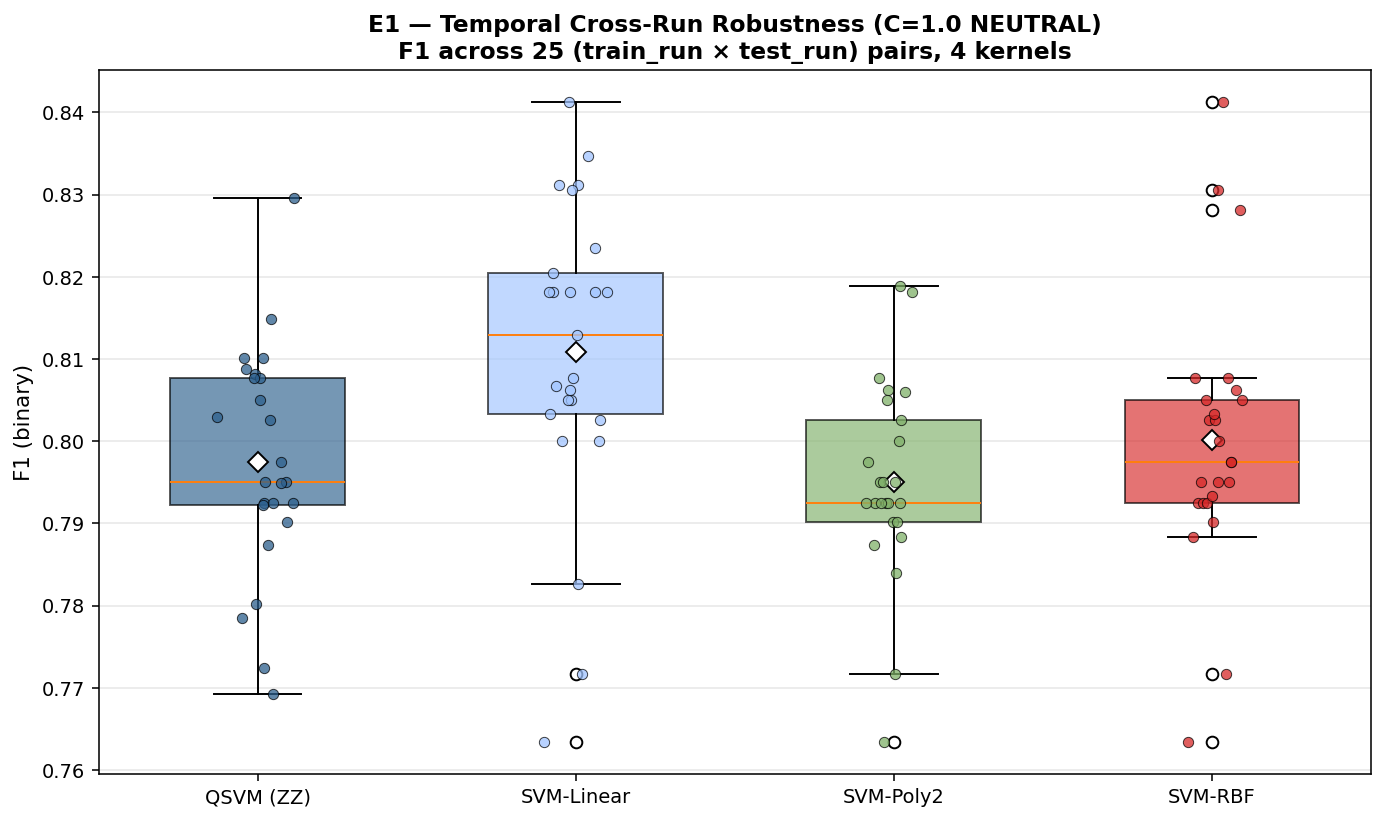

In [14]:
# ── Figure 1: E1 Temporal — boxplot F1 cho 4 kernels × 20 pairs ─────────────
fig1, ax1 = plt.subplots(figsize=(10, 6))
data_box = [temporal_df[temporal_df['kernel'] == k]['f1'].values for k in KERNEL_NAMES]
bp = ax1.boxplot(data_box, labels=[DISPLAY_NAMES[k] for k in KERNEL_NAMES],
                 patch_artist=True, widths=0.55, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='white',
                                markeredgecolor='black', markersize=7))
for patch, k in zip(bp['boxes'], KERNEL_NAMES):
    patch.set_facecolor(COLORS[k]); patch.set_alpha(0.65)
rng_jit = np.random.RandomState(0)
for i, k in enumerate(KERNEL_NAMES):
    ys = temporal_df[temporal_df['kernel'] == k]['f1'].values
    xs = rng_jit.normal(i + 1, 0.05, size=len(ys))
    ax1.scatter(xs, ys, color=COLORS[k], edgecolor='black',
                s=28, alpha=0.75, linewidth=0.5, zorder=3)
ax1.set_ylabel('F1 (binary)', fontsize=11)
ax1.set_title(f'E1 — Temporal Cross-Run Robustness (C=1.0 NEUTRAL)\n'
              f'F1 across 25 (train_run × test_run) pairs, 4 kernels',
              fontsize=12, fontweight='bold')
ax1.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
fig1_path = f'{REPORTS_DIR}/c4_temporal_C1.png'
fig1.savefig(fig1_path, dpi=140, bbox_inches='tight')
plt.close(fig1)
print(f'Saved: {fig1_path}')
display(Image(filename=fig1_path))


Saved: ../reports_unsw/c4_perturbation_C1.png


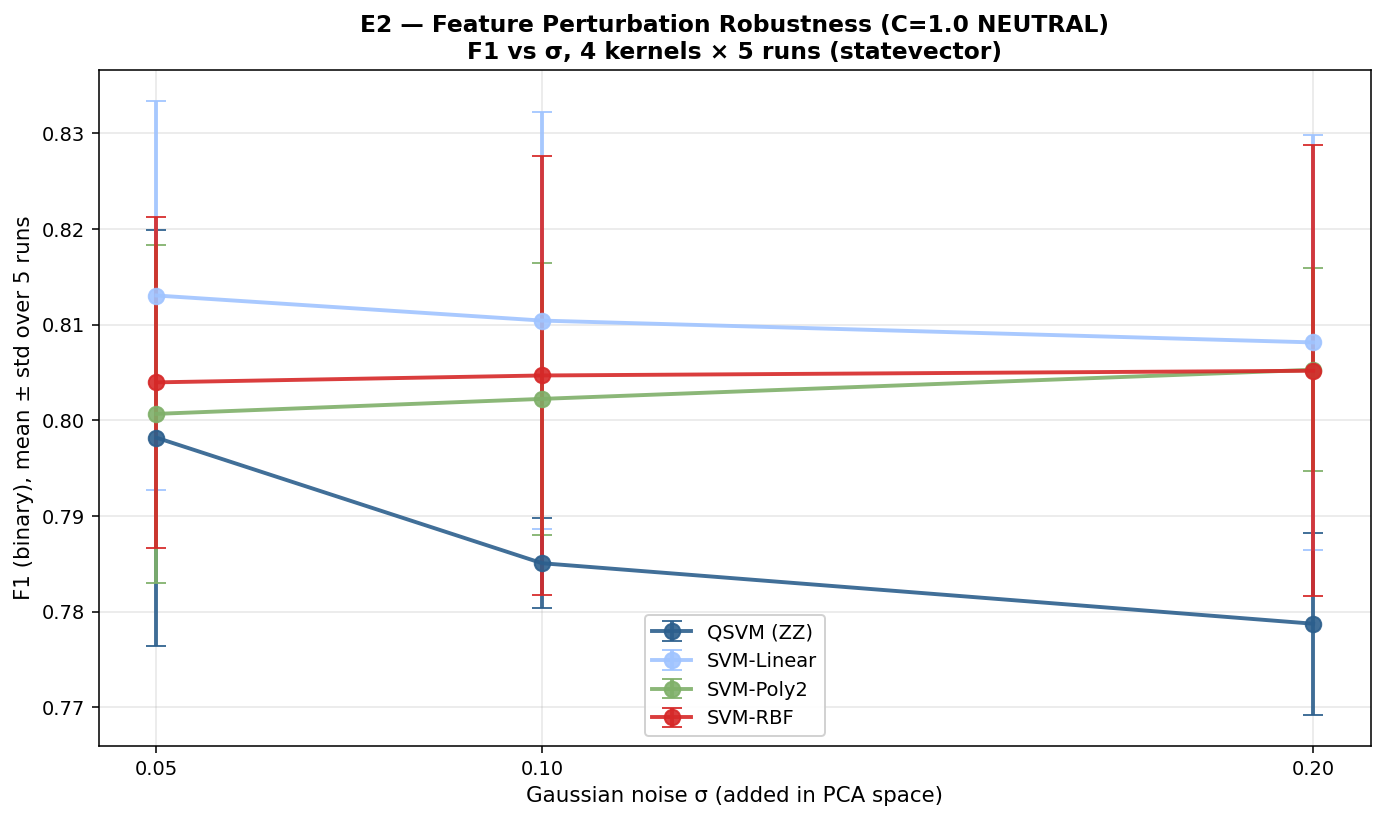

In [15]:
# ── Figure 2: E2 Perturbation — line F1 vs σ với errorbar, 4 kernels ────────
fig2, ax2 = plt.subplots(figsize=(10, 6))
sigmas = sorted(perturb_df['sigma'].unique())
for k in KERNEL_NAMES:
    means = [perturb_df[(perturb_df['kernel']==k) & (perturb_df['sigma']==s)]['f1'].mean()
             for s in sigmas]
    stds  = [perturb_df[(perturb_df['kernel']==k) & (perturb_df['sigma']==s)]['f1'].std()
             for s in sigmas]
    ax2.errorbar(sigmas, means, yerr=stds, marker='o', markersize=8,
                 linewidth=2, capsize=5, label=DISPLAY_NAMES[k],
                 color=COLORS[k], alpha=0.9)
ax2.set_xlabel('Gaussian noise σ (added in PCA space)', fontsize=11)
ax2.set_ylabel('F1 (binary), mean ± std over 5 runs', fontsize=11)
ax2.set_title(f'E2 — Feature Perturbation Robustness (C=1.0 NEUTRAL)\n'
              f'F1 vs σ, 4 kernels × {len(RUN_IDS)} runs (statevector)',
              fontsize=12, fontweight='bold')
ax2.set_xticks(sigmas)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', framealpha=0.9)
plt.tight_layout()
fig2_path = f'{REPORTS_DIR}/c4_perturbation_C1.png'
fig2.savefig(fig2_path, dpi=140, bbox_inches='tight')
plt.close(fig2)
print(f'Saved: {fig2_path}')
display(Image(filename=fig2_path))


Saved: ../reports_unsw/c4_prior_C1.png


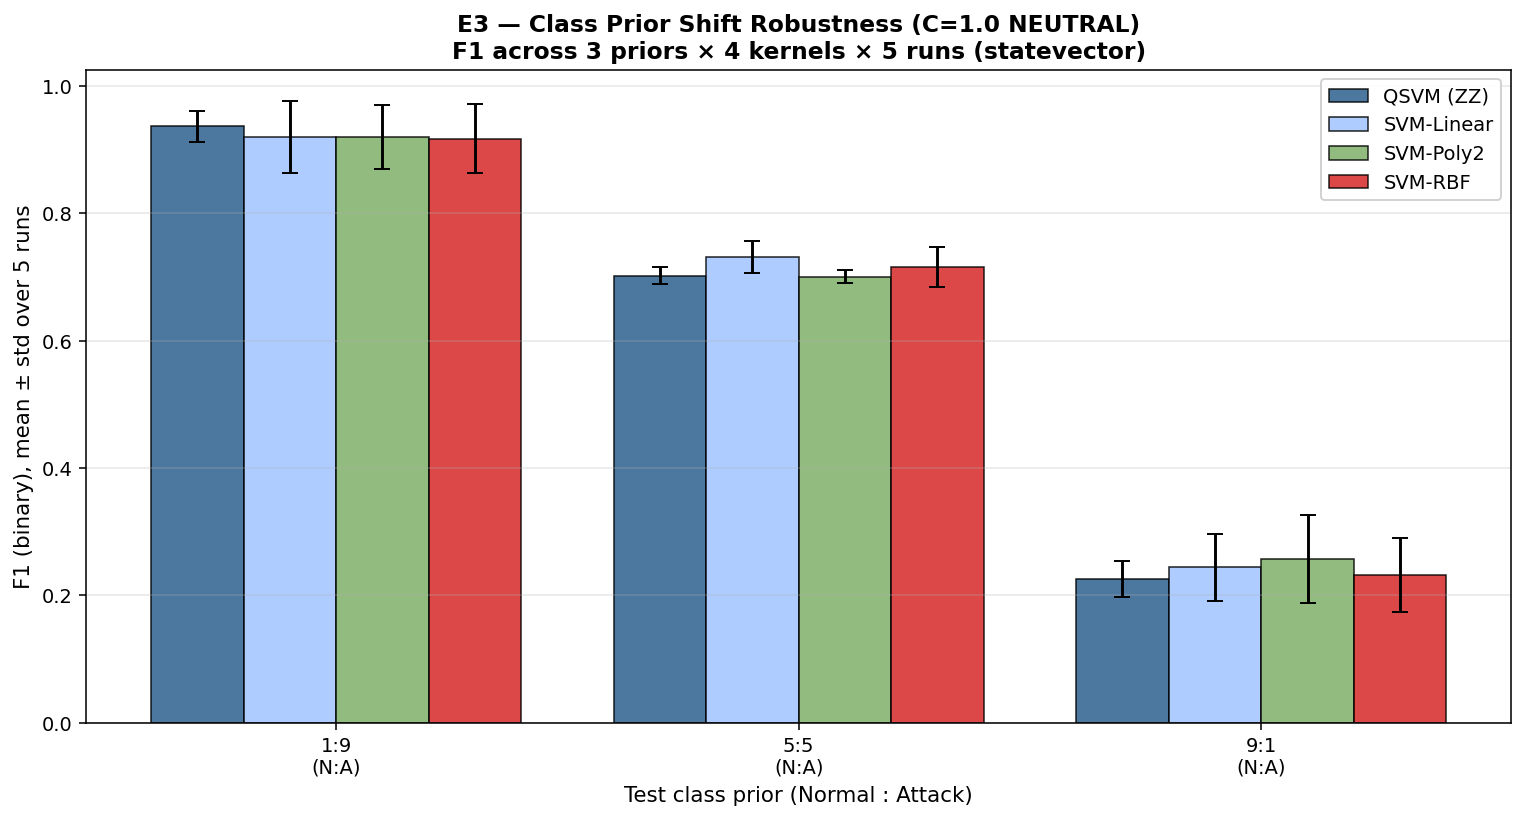

In [16]:
# ── Figure 3: E3 Prior Shift — grouped bar F1 ở 3 ratios × 4 kernels ───────
fig3, ax3 = plt.subplots(figsize=(11, 6))
ratios = PRIOR_RATIOS
ratio_labels = [f'{int(rn*10)}:{int(ra*10)}\n(N:A)' for (rn, ra) in ratios]
x = np.arange(len(ratios))
width = 0.20

for idx, k in enumerate(KERNEL_NAMES):
    means = []
    stds  = []
    for (rn, _) in ratios:
        vals = prior_df[(prior_df['kernel']==k) & (prior_df['ratio_normal']==rn)]['f1'].values
        means.append(vals.mean()); stds.append(vals.std())
    ax3.bar(x + (idx - 1.5) * width, means, width, yerr=stds,
            label=DISPLAY_NAMES[k], color=COLORS[k], alpha=0.85,
            capsize=4, edgecolor='black', linewidth=0.8)

ax3.set_xticks(x); ax3.set_xticklabels(ratio_labels)
ax3.set_xlabel('Test class prior (Normal : Attack)', fontsize=11)
ax3.set_ylabel('F1 (binary), mean ± std over 5 runs', fontsize=11)
ax3.set_title(f'E3 — Class Prior Shift Robustness (C=1.0 NEUTRAL)\n'
              f'F1 across 3 priors × 4 kernels × {len(RUN_IDS)} runs (statevector)',
              fontsize=12, fontweight='bold')
ax3.grid(True, axis='y', alpha=0.3)
ax3.legend(loc='best', framealpha=0.9)
plt.tight_layout()
fig3_path = f'{REPORTS_DIR}/c4_prior_C1.png'
fig3.savefig(fig3_path, dpi=140, bbox_inches='tight')
plt.close(fig3)
print(f'Saved: {fig3_path}')
display(Image(filename=fig3_path))


## 9. Save JSON — `models_unsw/c4_results.json`

In [17]:
def _summary_block(df_records, group_keys, kernel_names):
    """Helper: gom per_run/per_pair + summary mean±std (kèm precision/recall)."""
    out_summary = {}
    for k in kernel_names:
        sub = df_records[df_records['kernel'] == k]
        out_summary[k] = {
            'f1_mean':        float(sub['f1'].mean()),
            'f1_std':         float(sub['f1'].std()),
            'precision_mean': float(sub['precision'].mean()),
            'precision_std':  float(sub['precision'].std()),
            'recall_mean':    float(sub['recall'].mean()),
            'recall_std':     float(sub['recall'].std()),
            'acc_mean':       float(sub['accuracy'].mean()),
            'acc_std':        float(sub['accuracy'].std()),
            'kta_mean':       float(sub['kta'].mean()),
            'kta_std':        float(sub['kta'].std()),
            'tn_mean':        float(sub['tn'].mean()),
            'fp_mean':        float(sub['fp'].mean()),
            'fn_mean':        float(sub['fn'].mean()),
            'tp_mean':        float(sub['tp'].mean()),
            'C':              float(sub['C'].iloc[0]),
        }
    return out_summary

def _per_kernel_entry(row):
    """Helper: tạo 1 entry per-kernel với đầy đủ fields theo spec 1.5-redo."""
    return {
        'f1':        float(row['f1']),
        'precision': float(row['precision']),
        'recall':    float(row['recall']),
        'accuracy':  float(row['accuracy']),
        'tn': int(row['tn']), 'fp': int(row['fp']),
        'fn': int(row['fn']), 'tp': int(row['tp']),
        'kta':       float(row['kta']),
        'n_sv':      int(row['n_sv']),
        'C':         float(row['C']),
    }

# ── E1 Temporal ──
temporal_per_pair = []
for (i, j), g in temporal_df.groupby(['train_run','test_run']):
    entry = {'train_run': int(i), 'test_run': int(j)}
    for k in KERNEL_NAMES:
        row = g[g['kernel']==k].iloc[0]
        entry[k] = _per_kernel_entry(row)
    temporal_per_pair.append(entry)
temporal_block = {'per_pair': temporal_per_pair,
                  'summary':  _summary_block(temporal_df, ['train_run','test_run'], KERNEL_NAMES)}

# ── E2 Perturbation ──
perturb_per_sigma = []
for sigma in PERTURB_SIGMAS:
    sub = perturb_df[perturb_df['sigma'] == sigma]
    per_run_list = []
    for rid in RUN_IDS:
        srid = sub[sub['run'] == rid]
        entry = {'run': int(rid)}
        for k in KERNEL_NAMES:
            row = srid[srid['kernel']==k].iloc[0]
            entry[k] = _per_kernel_entry(row)
        per_run_list.append(entry)
    perturb_per_sigma.append({
        'sigma':   float(sigma),
        'per_run': per_run_list,
        'summary': _summary_block(sub, ['run'], KERNEL_NAMES),
    })
perturb_block = {'per_sigma': perturb_per_sigma}

# ── E3 Prior shift ──
prior_per_ratio = []
for (rn, ra) in PRIOR_RATIOS:
    sub = prior_df[(prior_df['ratio_normal']==rn) & (prior_df['ratio_attack']==ra)]
    per_run_list = []
    for rid in RUN_IDS:
        srid = sub[sub['run'] == rid]
        entry = {'run': int(rid),
                 'n_test':   int(srid['n_test'].iloc[0]),
                 'n_normal': int(srid['n_normal'].iloc[0]),
                 'n_attack': int(srid['n_attack'].iloc[0])}
        for k in KERNEL_NAMES:
            row = srid[srid['kernel']==k].iloc[0]
            entry[k] = _per_kernel_entry(row)
        per_run_list.append(entry)
    prior_per_ratio.append({
        'ratio_normal': float(rn), 'ratio_attack': float(ra),
        'per_run': per_run_list,
        'summary': _summary_block(sub, ['run'], KERNEL_NAMES),
    })
prior_block = {'per_ratio': prior_per_ratio}

# ── Metadata ──
metadata = {
    'regime':              'statevector',
    'backend':             'FidelityStatevectorKernel',
    'n_runs':              len(RUN_IDS),
    'C_strategy':          C_STRATEGY,
    'C_by_kernel':         {k: float(C_BY_KERNEL[k]) for k in KERNEL_NAMES},
    'compared_against':    RESULTS_JSON_OLD,
    'cache_reused_from':   [MULTIRUN_CACHE, C4_CACHE],
    'rationale':           (
        '1.6 (c1_dimreduction_multirun) found C=0.01 (tuned in 1.3) caused QSVM degeneracy '
        '(predict-all-attack). In 1.5 original, "robustness" of QSVM was an artifact: '
        'perturbation F1 invariant (constant prediction), temporal std=0.004 (trivially low), '
        'prior F1 matching degenerate formula F1=2p/(1+p). C=1.0 neutral surfaces real '
        'robustness pattern. Kernel matrices reused 100% — KTA must match 1.5.'
    ),
    'config_tag':          CONFIG_TAG,
    'experiments':         ['temporal', 'perturbation', 'prior_shift'],
    'temporal_pairs':      'all_cross',
    'n_temporal_pairs':    int(len(temporal_per_pair)),
    'perturbation_sigmas': [float(s) for s in PERTURB_SIGMAS],
    'prior_ratios':        [[float(rn), float(ra)] for (rn, ra) in PRIOR_RATIOS],
    'kernels':             KERNEL_NAMES,
    'pipeline':            {'K_select': K_SELECT, 'PCA_N': PCA_N,
                            'angle_max': float(ANGLE_MAX), 'zz_reps': ZZ_REPS,
                            'zz_entanglement': ZZ_ENT, 'poly_degree': POLY_DEGREE},
    'random_state':        RANDOM_STATE,
    'date':                datetime.date.today().isoformat(),
    'reports':             [
        f'{REPORTS_DIR}/c4_temporal_C1.png',
        f'{REPORTS_DIR}/c4_perturbation_C1.png',
        f'{REPORTS_DIR}/c4_prior_C1.png',
    ],
}

payload = {
    'temporal':    temporal_block,
    'perturbation':perturb_block,
    'prior_shift': prior_block,
    'metadata':    metadata,
}

with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)
print(f'Saved: {RESULTS_JSON}')
print(f'Size : {os.path.getsize(RESULTS_JSON)} bytes')


Saved: ../models_unsw/c4_results_C1.json


Size : 104871 bytes


## 9b. Sanity check: KTA cache-reuse (KTA mới == KTA 1.5 gốc)

Kernel matrix không phụ thuộc C → KTA QSVM cho cả 3 experiments phải khớp 1.5 đến nhiều chữ số. Cho temporal: per-pair (i,j) KTA chỉ phụ thuộc K_train(i) → check kta_mean của summary block.


In [18]:
# Sanity: KTA mean cho mỗi experiment × kernel phải khớp 1.5
print('=== KTA cache-reuse sanity check vs 1.5 ===')
print(f'{"Experiment":<24}  {"Kernel":>8}  {"KTA_new":>12}  {"KTA_old":>12}  {"|delta|":>10}  Status')
print('-' * 90)
max_delta = 0.0
checks = []

# E1 temporal
for k in KERNEL_NAMES:
    new_k = temporal_block['summary'][k]['kta_mean']
    old_k = old_results['temporal']['summary'][k]['kta_mean']
    d = abs(new_k - old_k); max_delta = max(max_delta, d)
    st = 'OK' if d < 1e-6 else 'FAIL'
    checks.append(d < 1e-6)
    print(f'{"E1 temporal":<24}  {k:>8}  {new_k:>12.8f}  {old_k:>12.8f}  {d:>10.2e}  {st}')

# E2 perturbation per sigma
for blk_new, blk_old in zip(perturb_block['per_sigma'], old_results['perturbation']['per_sigma']):
    sigma = blk_new['sigma']
    for k in KERNEL_NAMES:
        new_k = blk_new['summary'][k]['kta_mean']
        old_k = blk_old['summary'][k]['kta_mean']
        d = abs(new_k - old_k); max_delta = max(max_delta, d)
        st = 'OK' if d < 1e-6 else 'FAIL'
        checks.append(d < 1e-6)
        print(f'{f"E2 perturb σ={sigma}":<24}  {k:>8}  {new_k:>12.8f}  {old_k:>12.8f}  {d:>10.2e}  {st}')

# E3 prior per ratio
for blk_new, blk_old in zip(prior_block['per_ratio'], old_results['prior_shift']['per_ratio']):
    rn = blk_new['ratio_normal']; ra = blk_new['ratio_attack']
    for k in KERNEL_NAMES:
        new_k = blk_new['summary'][k]['kta_mean']
        old_k = blk_old['summary'][k]['kta_mean']
        d = abs(new_k - old_k); max_delta = max(max_delta, d)
        st = 'OK' if d < 1e-6 else 'FAIL'
        checks.append(d < 1e-6)
        print(f'{f"E3 prior {int(rn*10)}:{int(ra*10)}":<24}  {k:>8}  {new_k:>12.8f}  {old_k:>12.8f}  {d:>10.2e}  {st}')

assert all(checks), f'KTA mismatch (max |delta|={max_delta:.4e}) — cache reuse broken'
print(f'\n[OK] KTA cache-reuse verified ({len(checks)} checks) — max |delta|={max_delta:.2e}')


=== KTA cache-reuse sanity check vs 1.5 ===
Experiment                  Kernel       KTA_new       KTA_old     |delta|  Status
------------------------------------------------------------------------------------------
E1 temporal                quantum    0.19339507    0.19339507    0.00e+00  OK
E1 temporal                 linear    0.15783505    0.15783505    0.00e+00  OK
E1 temporal                   poly    0.11733173    0.11733173    0.00e+00  OK
E1 temporal                    rbf    0.23433528    0.23433528    0.00e+00  OK
E2 perturb σ=0.05          quantum    0.19339507    0.19339507    0.00e+00  OK
E2 perturb σ=0.05           linear    0.15783505    0.15783505    0.00e+00  OK
E2 perturb σ=0.05             poly    0.11733173    0.11733173    0.00e+00  OK
E2 perturb σ=0.05              rbf    0.23433528    0.23433528    0.00e+00  OK
E2 perturb σ=0.1           quantum    0.19339507    0.19339507    0.00e+00  OK
E2 perturb σ=0.1            linear    0.15783505    0.15783505    0.00e

## 9c. Bảng so sánh side-by-side: 1.5 (C tuned) vs 1.5-redo (C=1.0 neutral)

So sánh F1 cho TẤT CẢ entries trong 3 experiments. Cột "deg_dist" cho prior shift cho biết F1 lệch khỏi công thức degenerate `F1=2p/(1+p)` bao nhiêu (1.5 gốc khớp công thức đến 4 chữ số = QSVM predict-all-attack).


In [19]:
# ── E1 Temporal: bảng F1 mean per kernel ──
print('=' * 100)
print('  BẢNG SO SÁNH 1.5-REDO vs 1.5 GỐC (C=1.0 NEUTRAL vs C tuned)')
print('=' * 100)

print('\n[E1 Temporal — 25 cross-run pairs, mean F1]')
print(f'  {"Kernel":>8}  {"C_old":>6}  {"F1_old":>14}  {"C_new":>6}  {"F1_new":>14}  {"ΔF1":>8}  {"std_old":>8}  {"std_new":>8}')
print('  ' + '-' * 96)
for k in KERNEL_NAMES:
    so = old_results['temporal']['summary'][k]
    sn = temporal_block['summary'][k]
    co = old_results['metadata']['C_by_kernel'][k]
    cn = sn['C']
    df1 = sn['f1_mean'] - so['f1_mean']
    print(f'  {k:>8}  {co:>6g}  {so["f1_mean"]:.4f}±{so["f1_std"]:.3f}  {cn:>6g}  '
          f'{sn["f1_mean"]:.4f}±{sn["f1_std"]:.3f}  {df1:+7.4f}  {so["f1_std"]:>8.4f}  {sn["f1_std"]:>8.4f}')

# ── E2 Perturbation: bảng F1 per (sigma, kernel) ──
print('\n[E2 Perturbation — F1 mean per σ]')
print(f'  {"Kernel":>8}  {"σ":>6}  {"C_old":>6}  {"F1_old":>14}  {"C_new":>6}  {"F1_new":>14}  {"ΔF1":>8}')
print('  ' + '-' * 88)
for k in KERNEL_NAMES:
    for blk_new, blk_old in zip(perturb_block['per_sigma'], old_results['perturbation']['per_sigma']):
        sigma = blk_new['sigma']
        so = blk_old['summary'][k]
        sn = blk_new['summary'][k]
        co = old_results['metadata']['C_by_kernel'][k]
        cn = sn['C']
        df1 = sn['f1_mean'] - so['f1_mean']
        print(f'  {k:>8}  {sigma:>6.2f}  {co:>6g}  {so["f1_mean"]:.4f}±{so["f1_std"]:.3f}  {cn:>6g}  '
              f'{sn["f1_mean"]:.4f}±{sn["f1_std"]:.3f}  {df1:+7.4f}')
    print('  ' + '-' * 88)

# QSVM perturbation invariance check: range F1 across sigmas
q_f1_per_sigma_old = [b['summary']['quantum']['f1_mean'] for b in old_results['perturbation']['per_sigma']]
q_f1_per_sigma_new = [b['summary']['quantum']['f1_mean'] for b in perturb_block['per_sigma']]
print(f'\n  QSVM F1 range across σ (max - min):')
print(f'    Old (1.5): {max(q_f1_per_sigma_old) - min(q_f1_per_sigma_old):.6f}  '
      f'→ {q_f1_per_sigma_old}  (invariant = degeneracy)')
print(f'    New (C=1): {max(q_f1_per_sigma_new) - min(q_f1_per_sigma_new):.6f}  '
      f'→ {q_f1_per_sigma_new}  (sensitive = non-degenerate)')

# ── E3 Prior Shift: bảng F1 + deg_dist (lệch khỏi công thức degenerate) ──
def f1_degenerate(ratio_attack):
    # Nếu predict-all-attack: TP=n_attack, FP=n_normal, FN=0, TN=0
    # → precision = n_attack/(n_attack+n_normal) = ra; recall = 1
    # → F1 = 2*ra*1/(ra+1) = 2*ra/(1+ra)
    return 2 * ratio_attack / (1 + ratio_attack)

print('\n[E3 Prior Shift — F1 mean per ratio Normal:Attack]')
print(f'  {"Kernel":>8}  {"Ratio":>9}  {"F1_deg_formula":>14}  {"F1_old":>14}  {"deg_dist_old":>12}  {"F1_new":>14}  {"deg_dist_new":>12}')
print('  ' + '-' * 100)
for k in KERNEL_NAMES:
    for blk_new, blk_old in zip(prior_block['per_ratio'], old_results['prior_shift']['per_ratio']):
        rn, ra = blk_new['ratio_normal'], blk_new['ratio_attack']
        so = blk_old['summary'][k]
        sn = blk_new['summary'][k]
        f1_deg = f1_degenerate(ra)
        dist_old = abs(so['f1_mean'] - f1_deg)
        dist_new = abs(sn['f1_mean'] - f1_deg)
        print(f'  {k:>8}  {int(rn*10)}:{int(ra*10):<7}  {f1_deg:>14.4f}  '
              f'{so["f1_mean"]:.4f}±{so["f1_std"]:.3f}  {dist_old:>12.4f}  '
              f'{sn["f1_mean"]:.4f}±{sn["f1_std"]:.3f}  {dist_new:>12.4f}')
    print('  ' + '-' * 100)

# QSVM degeneracy signature check
print('\n  QSVM degeneracy signature (prior shift) — deg_dist = |F1 - 2p/(1+p)|:')
for blk_new, blk_old in zip(prior_block['per_ratio'], old_results['prior_shift']['per_ratio']):
    rn, ra = blk_new['ratio_normal'], blk_new['ratio_attack']
    f1_deg = f1_degenerate(ra)
    dist_old = abs(blk_old['summary']['quantum']['f1_mean'] - f1_deg)
    dist_new = abs(blk_new['summary']['quantum']['f1_mean'] - f1_deg)
    print(f'    {int(rn*10)}:{int(ra*10)}  deg_dist_old={dist_old:.6f}  deg_dist_new={dist_new:.6f}  '
          f'→ old {"≈ degenerate" if dist_old < 0.01 else "non-degenerate"}, '
          f'new {"still degenerate" if dist_new < 0.01 else "non-degenerate (escaped)"}')

# QSVM TN comparison
print('\n  QSVM TN_mean (cm[0][0]) per experiment — TN > 0 ⇒ thoát degeneracy:')
tn_temp = temporal_block['summary']['quantum']['tn_mean']
print(f'    E1 temporal               : TN_mean = {tn_temp:.2f}')
for blk in perturb_block['per_sigma']:
    print(f'    E2 perturb σ={blk["sigma"]:<5g}      : TN_mean = {blk["summary"]["quantum"]["tn_mean"]:.2f}')
for blk in prior_block['per_ratio']:
    rn, ra = blk['ratio_normal'], blk['ratio_attack']
    print(f'    E3 prior {int(rn*10)}:{int(ra*10)}                : TN_mean = {blk["summary"]["quantum"]["tn_mean"]:.2f}')

# Append comparison vào JSON
payload['comparison_vs_1_5'] = {
    'old_results_path':    RESULTS_JSON_OLD,
    'qsvm_perturb_range_old': float(max(q_f1_per_sigma_old) - min(q_f1_per_sigma_old)),
    'qsvm_perturb_range_new': float(max(q_f1_per_sigma_new) - min(q_f1_per_sigma_new)),
    'qsvm_prior_deg_dist': [
        {
            'ratio': [float(b['ratio_normal']), float(b['ratio_attack'])],
            'deg_dist_old': float(abs(bo['summary']['quantum']['f1_mean'] - f1_degenerate(b['ratio_attack']))),
            'deg_dist_new': float(abs(b['summary']['quantum']['f1_mean'] - f1_degenerate(b['ratio_attack']))),
        }
        for b, bo in zip(prior_block['per_ratio'], old_results['prior_shift']['per_ratio'])
    ],
    'note': '1.5 gốc: QSVM degenerate (F1 invariant với σ, prior F1 khớp 2p/(1+p)). '
            '1.5-redo C=1.0: QSVM sensitive với σ, prior F1 lệch khỏi formula.',
}
with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)
print(f'\n[UPDATED] {RESULTS_JSON} (appended comparison_vs_1_5)')


  BẢNG SO SÁNH 1.5-REDO vs 1.5 GỐC (C=1.0 NEUTRAL vs C tuned)

[E1 Temporal — 25 cross-run pairs, mean F1]
    Kernel   C_old          F1_old   C_new          F1_new       ΔF1   std_old   std_new
  ------------------------------------------------------------------------------------------------
   quantum    0.01  0.7760±0.004       1  0.7975±0.014  +0.0215    0.0037    0.0138
    linear     0.1  0.8069±0.019       1  0.8108±0.019  +0.0039    0.0191    0.0186
      poly     0.1  0.8022±0.017       1  0.7951±0.012  -0.0072    0.0173    0.0122
       rbf       1  0.8002±0.016       1  0.8002±0.016  +0.0000    0.0162    0.0162

[E2 Perturbation — F1 mean per σ]
    Kernel       σ   C_old          F1_old   C_new          F1_new       ΔF1
  ----------------------------------------------------------------------------------------
   quantum    0.05    0.01  0.7760±0.004       1  0.7982±0.022  +0.0222
   quantum    0.10    0.01  0.7760±0.004       1  0.7851±0.005  +0.0091
   quantum    0.20    

## 10. Summary — Bảng F1 mean±std + Insight

In [20]:
print('=' * 88)
print('  UNSW-NB15 — C4 ROBUSTNESS MULTI-RUN STATEVECTOR (1.5-REDO, C=1.0 NEUTRAL)')
print('=' * 88)
print(f'  CONFIG_TAG : {CONFIG_TAG}')
print(f'  C_STRATEGY : {C_STRATEGY}')
print(f'  Compared vs: {RESULTS_JSON_OLD}  (1.5 gốc, C tuned)')
print(f'  Regime     : statevector (noiseless)')
print(f'  Cache reuse: 100% từ {MULTIRUN_CACHE} + {C4_CACHE}')
print(f'  Runs       : {len(RUN_IDS)} | Kernels: {KERNEL_NAMES}')
print()

# ── E1 ──
print('── E1: Temporal Cross-Run (mean ± std over all pairs) ───────────────────────')
print(f'  {"Kernel":>10}  {"F1":>16}  {"Accuracy":>16}  {"KTA":>16}')
print('  ' + '-' * 70)
for k in KERNEL_NAMES:
    s = temporal_block['summary'][k]
    print(f'  {k:>10}  {s["f1_mean"]:.4f}±{s["f1_std"]:.4f}    '
          f'{s["acc_mean"]:.4f}±{s["acc_std"]:.4f}    '
          f'{s["kta_mean"]:.4f}±{s["kta_std"]:.4f}')

# ── E2 ──
print()
print('── E2: Feature Perturbation (mean ± std over 5 runs, per σ) ──────────────────')
print(f'  {"Kernel":>10}  ' + '  '.join([f'σ={s:<6g}' for s in PERTURB_SIGMAS]))
print('  ' + '-' * 70)
for k in KERNEL_NAMES:
    row = []
    for blk in perturb_block['per_sigma']:
        s = blk['summary'][k]
        row.append(f'{s["f1_mean"]:.3f}±{s["f1_std"]:.3f}')
    print(f'  {k:>10}  ' + '  '.join([f'{v:<10}' for v in row]))

# ── E3 ──
print()
print('── E3: Class Prior Shift (mean ± std over 5 runs, per ratio N:A) ─────────────')
print(f'  {"Kernel":>10}  ' + '  '.join([f'{int(rn*10)}:{int(ra*10):<6}' for (rn,ra) in PRIOR_RATIOS]))
print('  ' + '-' * 70)
for k in KERNEL_NAMES:
    row = []
    for blk in prior_block['per_ratio']:
        s = blk['summary'][k]
        row.append(f'{s["f1_mean"]:.3f}±{s["f1_std"]:.3f}')
    print(f'  {k:>10}  ' + '  '.join([f'{v:<10}' for v in row]))

# ── QSVM vs RBF head-to-head ──
print()
print('  QSVM vs RBF head-to-head (Δ F1 = QSVM - RBF, mean):')
e1 = temporal_block['summary']
print(f'    E1 temporal           : Δ = {e1["quantum"]["f1_mean"] - e1["rbf"]["f1_mean"]:+.4f}')
for blk in perturb_block['per_sigma']:
    s = blk['summary']
    print(f'    E2 σ={blk["sigma"]:<5g}            : Δ = {s["quantum"]["f1_mean"] - s["rbf"]["f1_mean"]:+.4f}')
for blk in prior_block['per_ratio']:
    s = blk['summary']
    print(f'    E3 ({int(blk["ratio_normal"]*10)}:{int(blk["ratio_attack"]*10)})              : Δ = {s["quantum"]["f1_mean"] - s["rbf"]["f1_mean"]:+.4f}')
print('=' * 88)
print('DONE.')


  UNSW-NB15 — C4 ROBUSTNESS MULTI-RUN STATEVECTOR (1.5-REDO, C=1.0 NEUTRAL)
  CONFIG_TAG : r2_full_k35_p4_cv5_sf1_run1
  C_STRATEGY : neutral_C1_no_retune
  Compared vs: ../models_unsw/c4_results.json  (1.5 gốc, C tuned)
  Regime     : statevector (noiseless)
  Cache reuse: 100% từ ../models_unsw/qsvm_cache/multirun + ../models_unsw/qsvm_cache/c4
  Runs       : 5 | Kernels: ['quantum', 'linear', 'poly', 'rbf']

── E1: Temporal Cross-Run (mean ± std over all pairs) ───────────────────────
      Kernel                F1          Accuracy               KTA
  ----------------------------------------------------------------------
     quantum  0.7975±0.0138    0.6948±0.0295    0.1934±0.0452
      linear  0.8108±0.0186    0.7276±0.0344    0.1578±0.0451
        poly  0.7951±0.0122    0.6972±0.0337    0.1173±0.0528
         rbf  0.8002±0.0162    0.7072±0.0424    0.2343±0.0494

── E2: Feature Perturbation (mean ± std over 5 runs, per σ) ──────────────────
      Kernel  σ=0.05    σ=0.1     σ=0.2